<a href="https://colab.research.google.com/github/pxu/Generative_Deep_Learning_2nd_Edition/blob/main/notebooks/07_ebm/01_ebm/ebm_assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡️ Energy-Based Models

In this notebook, we'll walk through the steps required to train your own Energy Based Model to predict the distribution of a demo dataset

The code is adapted from the excellent ['Deep Energy-Based Generative Models' tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html) created by Phillip Lippe.

In [89]:
import numpy as np

import tensorflow as tf
from tensorflow.keras import (
    datasets,
    layers,
    models,
    optimizers,
    activations,
    metrics,
    callbacks,
)

import random

In [90]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

## 0. Parameters <a name="parameters"></a>

In [91]:

# Using 30 Langevin sampling steps provides stronger mixing and helps the
# sampler move beyond random noise toward meaningful digit structures.
# Fewer steps (e.g., 10–20) made the sampling chains move too little, which
# resulted in early training images remaining mostly gray noise.
STEPS = 20   # Reduced from 60.

# A moderate step size helps the sampler make steady progress along the
# energy gradient without overshooting. This improves stability while still
# allowing the sampler to form clearer digit-like patterns over time.
STEP_SIZE = 6   # Reduced from 10.

# A larger batch size reduces the number of updates per epoch, which speeds
# up training while still covering the full dataset in each epoch.
BATCH_SIZE = 256   # Increased from 128.

# A lower learning rate stabilizes long training runs and prevents energy
# divergence or collapse in later epochs.
LEARNING_RATE = 5e-5   # Reduced from 0.0001.

EPOCHS =  40 # 120   # Increasd from 60, Required by the assignment.


IMAGE_SIZE = 32
CHANNELS = 1

NOISE = 0.005
ALPHA = 0.1
GRADIENT_CLIP = 0.03
BUFFER_SIZE = 8192

LOAD_MODEL = False

In [92]:
# Load the data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

In [93]:
# Preprocess the data


def preprocess(imgs):
    """
    Normalize and reshape the images
    """
    imgs = (imgs.astype("float32") - 127.5) / 127.5
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=-1.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs


x_train = preprocess(x_train)
x_test = preprocess(x_test)

In [94]:
x_train = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)
x_test = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

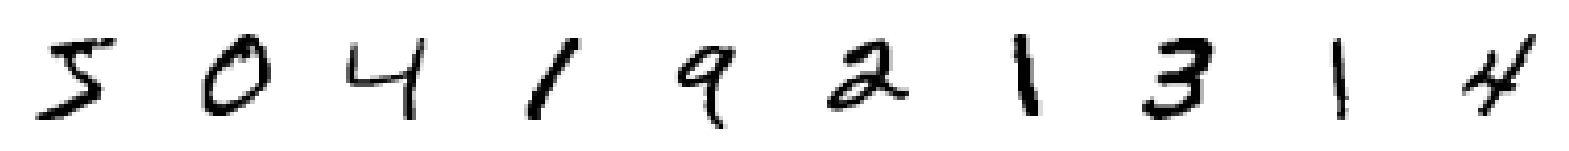

In [95]:
# Show some items of clothing from the training set
train_sample = sample_batch(x_train)
display(train_sample)

## 2. Build the EBM network <a name="train"></a>

In [96]:
ebm_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = layers.Conv2D(
    16, kernel_size=5, strides=2, padding="same", activation=activations.swish
)(ebm_input)
x = layers.Conv2D(
    32, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation=activations.swish)(x)
ebm_output = layers.Dense(1)(x)
model = models.Model(ebm_input, ebm_output)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,993 (300.75 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
if LOAD_MODEL:
    model.load_weights("./models/model.h5")

## 2. Set up a Langevin sampler function <a name="sampler"></a>

In [98]:
# Function to generate samples using Langevin Dynamics
def generate_samples(
    model, inp_imgs, steps, step_size, noise, return_img_per_step=False
):
    imgs_per_step = []
    for _ in range(steps):
        inp_imgs += tf.random.normal(inp_imgs.shape, mean=0, stddev=noise)
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        with tf.GradientTape() as tape:
            tape.watch(inp_imgs)
            out_score = model(inp_imgs)
        grads = tape.gradient(out_score, inp_imgs)
        grads = tf.clip_by_value(grads, -GRADIENT_CLIP, GRADIENT_CLIP)
        inp_imgs += step_size * grads
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        if return_img_per_step:
            imgs_per_step.append(inp_imgs)
    if return_img_per_step:
        return tf.stack(imgs_per_step, axis=0)
    else:
        return inp_imgs

## 3. Set up a buffer to store examples <a name="buffer"></a>

In [99]:
class Buffer:
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.examples = [
            tf.random.uniform(shape=(1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2
            - 1
            for _ in range(BATCH_SIZE)
        ]

    def sample_new_exmps(self, steps, step_size, noise):
        n_new = np.random.binomial(BATCH_SIZE, 0.05)
        rand_imgs = (
            tf.random.uniform((n_new, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
        )
        old_imgs = tf.concat(
            random.choices(self.examples, k=BATCH_SIZE - n_new), axis=0
        )
        inp_imgs = tf.concat([rand_imgs, old_imgs], axis=0)
        inp_imgs = generate_samples(
            self.model, inp_imgs, steps=steps, step_size=step_size, noise=noise
        )
        self.examples = tf.split(inp_imgs, BATCH_SIZE, axis=0) + self.examples
        self.examples = self.examples[:BUFFER_SIZE]
        return inp_imgs

In [100]:
class EBM(models.Model):
    def __init__(self):
        super(EBM, self).__init__()
        self.model = model
        self.buffer = Buffer(self.model)
        self.alpha = ALPHA
        self.loss_metric = metrics.Mean(name="loss")
        self.reg_loss_metric = metrics.Mean(name="reg")
        self.cdiv_loss_metric = metrics.Mean(name="cdiv")
        self.real_out_metric = metrics.Mean(name="real")
        self.fake_out_metric = metrics.Mean(name="fake")

    @property
    def metrics(self):
        return [
            self.loss_metric,
            self.reg_loss_metric,
            self.cdiv_loss_metric,
            self.real_out_metric,
            self.fake_out_metric,
        ]

    def train_step(self, real_imgs):
        real_imgs += tf.random.normal(
            shape=tf.shape(real_imgs), mean=0, stddev=NOISE
        )
        real_imgs = tf.clip_by_value(real_imgs, -1.0, 1.0)
        fake_imgs = self.buffer.sample_new_exmps(
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        with tf.GradientTape() as training_tape:
            real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
            cdiv_loss = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
                real_out, axis=0
            )
            reg_loss = self.alpha * tf.reduce_mean(
                real_out**2 + fake_out**2, axis=0
            )
            loss = cdiv_loss + reg_loss
        grads = training_tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_variables)
        )
        self.loss_metric.update_state(loss)
        self.reg_loss_metric.update_state(reg_loss)
        self.cdiv_loss_metric.update_state(cdiv_loss)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, real_imgs):
        batch_size = real_imgs.shape[0]
        fake_imgs = (
            tf.random.uniform((batch_size, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
            * 2
            - 1
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
        cdiv = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
            real_out, axis=0
        )
        self.cdiv_loss_metric.update_state(cdiv)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics[2:]}

In [101]:
ebm = EBM()

## 3. Train the EBM network <a name="train"></a>

In [102]:
# Compile and train the model
ebm.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), run_eagerly=True
)

In [103]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


# This callback generates sample images at the end of each epoch.
# We reduce the Langevin sampling steps from 1000 to 200 to significantly
# speed up training while still preserving good visual sample quality.
# This change does NOT affect model training, only visualization speed.

class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        super().__init__()
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        # -----------------------------------------
        # 1. Generate initial random noise images
        # -----------------------------------------
        start_imgs = (
            np.random.uniform(
                size=(self.num_img, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            ) * 2 - 1
        )

        # ------------------------------------------------------------
        # 2. Generate images using Langevin Dynamics
        # NOTE: steps reduced to 200 (from original 1000):
        # - This speeds up training significantly.
        # - 200 steps still produce clear samples.
        # - This only affects visualization, not training quality.
        # ------------------------------------------------------------
        generated_images = generate_samples(
            ebm.model,
            start_imgs,
            steps=200,              # Reduced from 1000 for faster training
            step_size=STEP_SIZE,
            noise=NOISE,
            return_img_per_step=False,
        ).numpy()

        # Save generated samples for visualization
        display(
            generated_images,
            save_to="./output/generated_img_%03d.png" % epoch,
        )

        # ------------------------------------------------------------
        # 3. Display negative samples stored in the replay buffer
        # ------------------------------------------------------------
        example_images = tf.concat(
            random.choices(ebm.buffer.examples, k=10), axis=0
        ).numpy()

        display(
            example_images,
            save_to="./output/example_img_%03d.png" % epoch,
        )


# Create the callback instance
image_generator_callback = ImageGenerator(num_img=10)

In [104]:
import os
if not os.path.exists("models"):
    os.makedirs("models")

if not os.path.exists("output"):
    os.makedirs("output")

Epoch 1/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - cdiv: -0.1483 - fake: 0.1983 - loss: -0.1060 - real: 0.3466 - reg: 0.0422
Saved to ./output/generated_img_000.png


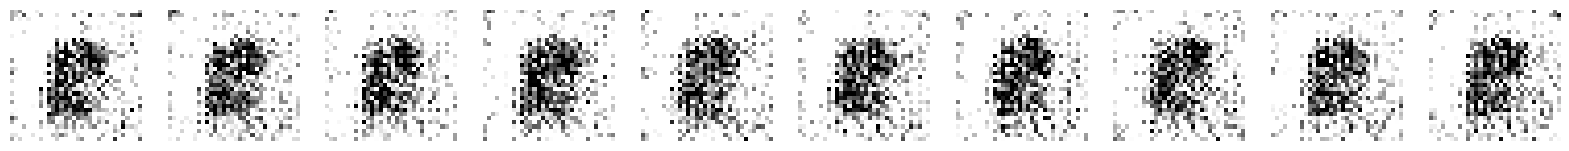


Saved to ./output/example_img_000.png


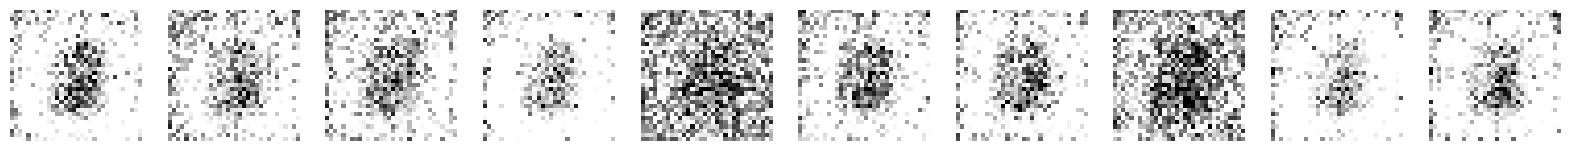

235/235 ━━━━━━━━━━━━━━━━━━━━ 148s 631ms/step - cdiv: -0.2364 - fake: 0.4025 - loss: -0.1522 - real: 0.6389 - reg: 0.0842 - val_cdiv: -0.9766 - val_fake: -0.2604 - val_real: 0.7162
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - cdiv: -0.1910 - fake: 0.4717 - loss: -0.1158 - real: 0.6627 - reg: 0.0752
Saved to ./output/generated_img_001.png


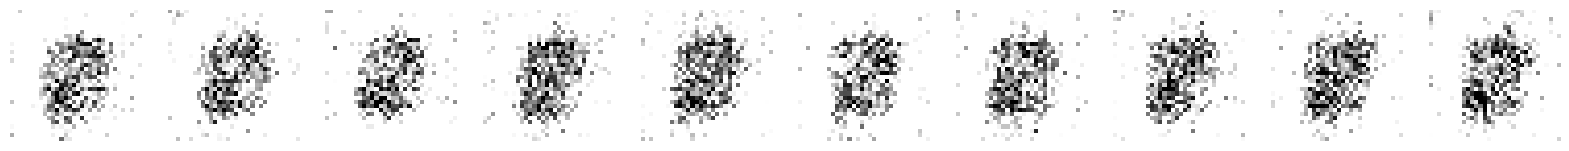


Saved to ./output/example_img_001.png


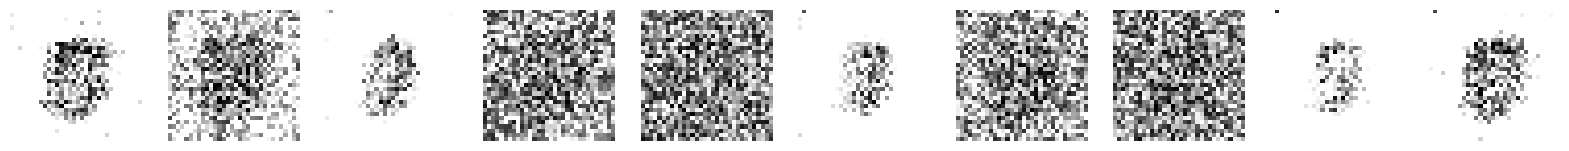

235/235 ━━━━━━━━━━━━━━━━━━━━ 152s 647ms/step - cdiv: -0.1943 - fake: 0.4328 - loss: -0.1252 - real: 0.6270 - reg: 0.0690 - val_cdiv: -1.2031 - val_fake: -0.6393 - val_real: 0.5638
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - cdiv: -0.2124 - fake: 0.2760 - loss: -0.1621 - real: 0.4884 - reg: 0.0503
Saved to ./output/generated_img_002.png


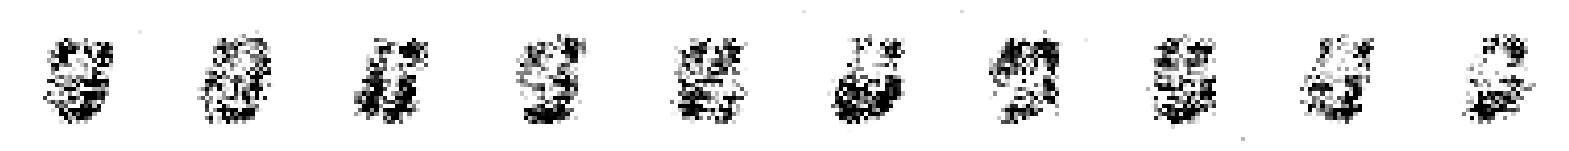


Saved to ./output/example_img_002.png


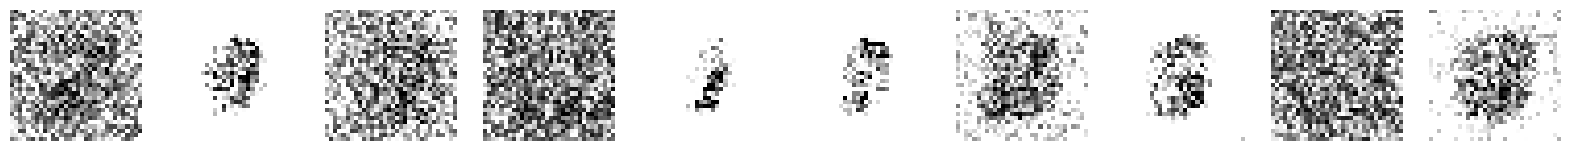

235/235 ━━━━━━━━━━━━━━━━━━━━ 152s 648ms/step - cdiv: -0.2243 - fake: 0.2008 - loss: -0.1764 - real: 0.4251 - reg: 0.0479 - val_cdiv: -2.4491 - val_fake: -2.2252 - val_real: 0.2239
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - cdiv: -0.2664 - fake: -0.0203 - loss: -0.1966 - real: 0.2461 - reg: 0.0698
Saved to ./output/generated_img_003.png


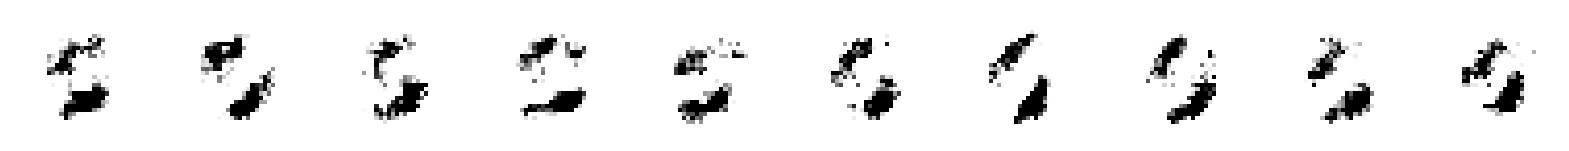


Saved to ./output/example_img_003.png


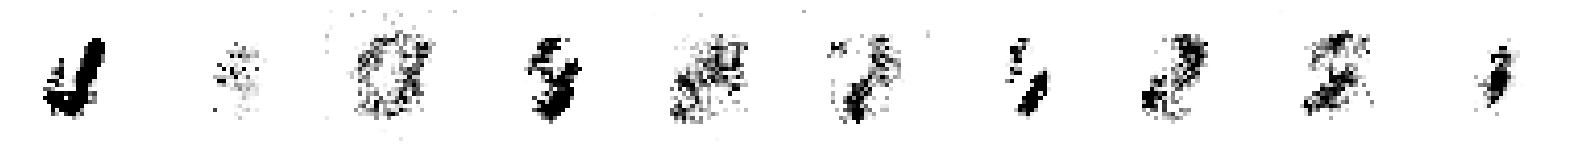

235/235 ━━━━━━━━━━━━━━━━━━━━ 153s 652ms/step - cdiv: -0.2253 - fake: -0.0359 - loss: -0.1516 - real: 0.1894 - reg: 0.0737 - val_cdiv: -4.5997 - val_fake: -4.6271 - val_real: -0.0274
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - cdiv: -0.1316 - fake: -0.0491 - loss: -0.0764 - real: 0.0825 - reg: 0.0552
Saved to ./output/generated_img_004.png


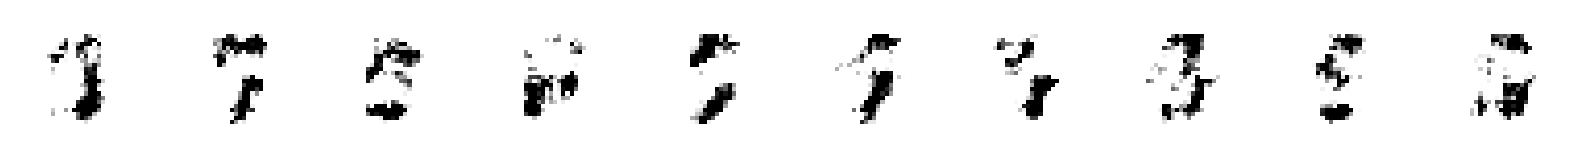


Saved to ./output/example_img_004.png


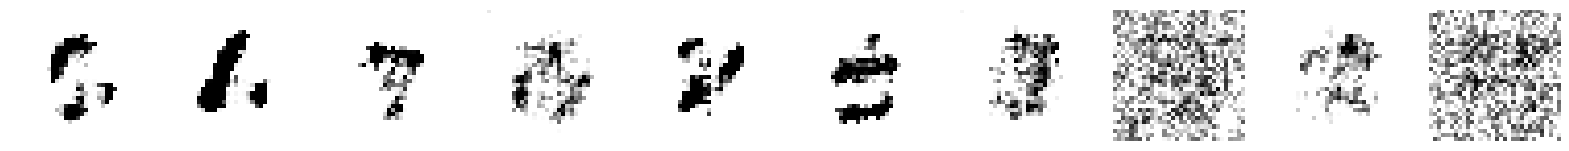

235/235 ━━━━━━━━━━━━━━━━━━━━ 153s 652ms/step - cdiv: -0.1289 - fake: -0.0456 - loss: -0.0751 - real: 0.0833 - reg: 0.0537 - val_cdiv: -5.6063 - val_fake: -5.5879 - val_real: 0.0184
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - cdiv: -0.1153 - fake: -0.0493 - loss: -0.0667 - real: 0.0660 - reg: 0.0486
Saved to ./output/generated_img_005.png


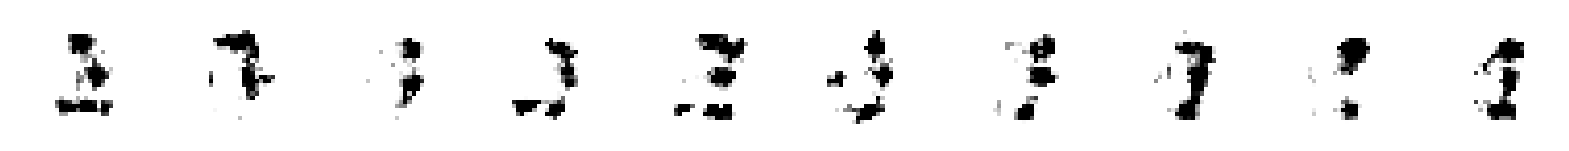


Saved to ./output/example_img_005.png


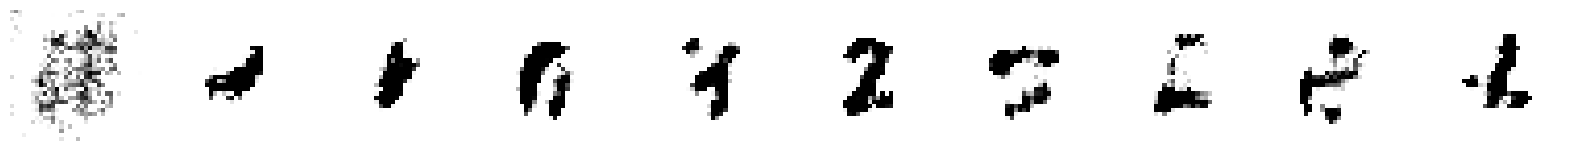

235/235 ━━━━━━━━━━━━━━━━━━━━ 154s 656ms/step - cdiv: -0.1100 - fake: -0.0424 - loss: -0.0624 - real: 0.0676 - reg: 0.0475 - val_cdiv: -6.7149 - val_fake: -6.6567 - val_real: 0.0582
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - cdiv: -0.0938 - fake: -0.0354 - loss: -0.0561 - real: 0.0584 - reg: 0.0378
Saved to ./output/generated_img_006.png


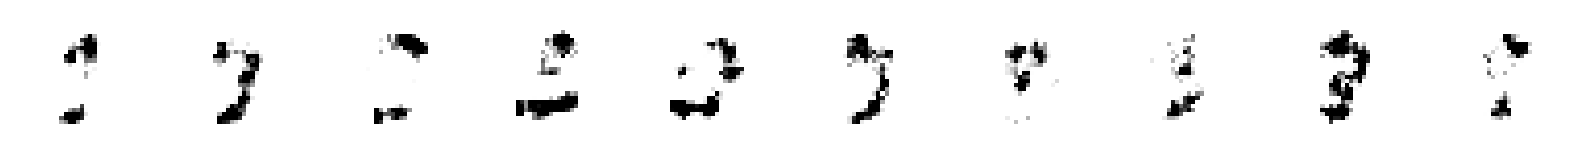


Saved to ./output/example_img_006.png


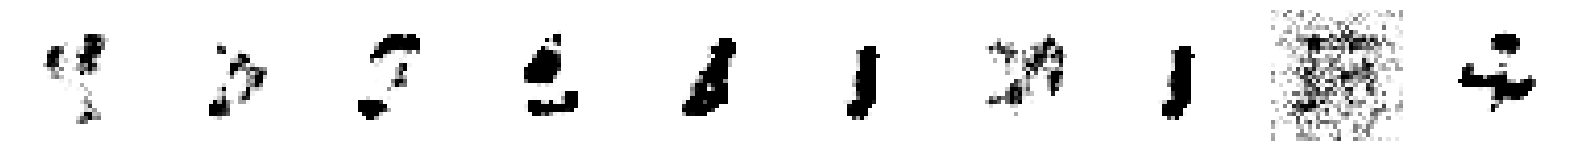

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 677ms/step - cdiv: -0.0838 - fake: -0.0290 - loss: -0.0496 - real: 0.0547 - reg: 0.0342 - val_cdiv: -8.0583 - val_fake: -7.9858 - val_real: 0.0726
Epoch 8/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - cdiv: -0.0671 - fake: -0.0222 - loss: -0.0426 - real: 0.0449 - reg: 0.0245
Saved to ./output/generated_img_007.png


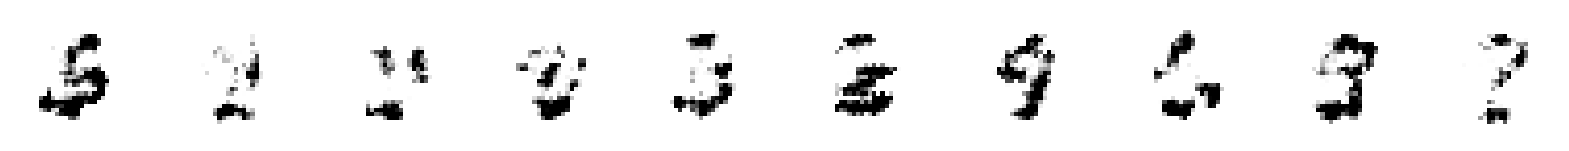


Saved to ./output/example_img_007.png


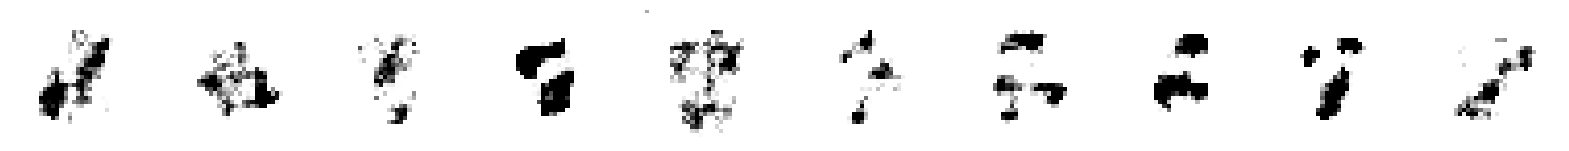

235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 668ms/step - cdiv: -0.0531 - fake: -0.0137 - loss: -0.0326 - real: 0.0394 - reg: 0.0205 - val_cdiv: -9.7059 - val_fake: -9.6007 - val_real: 0.1053
Epoch 9/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - cdiv: -0.0348 - fake: -0.0102 - loss: -0.0242 - real: 0.0246 - reg: 0.0106
Saved to ./output/generated_img_008.png


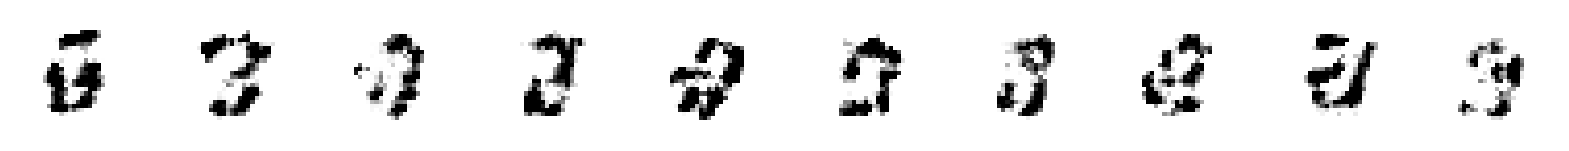


Saved to ./output/example_img_008.png


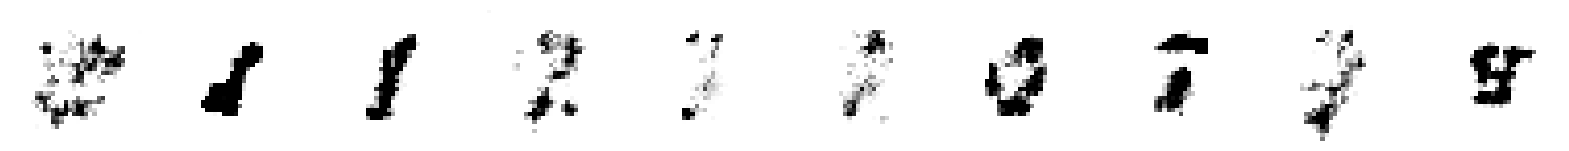

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 662ms/step - cdiv: -0.0317 - fake: -0.0109 - loss: -0.0217 - real: 0.0207 - reg: 0.0099 - val_cdiv: -11.5195 - val_fake: -11.3646 - val_real: 0.1550
Epoch 10/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - cdiv: -0.0327 - fake: -0.0087 - loss: -0.0234 - real: 0.0240 - reg: 0.0094
Saved to ./output/generated_img_009.png


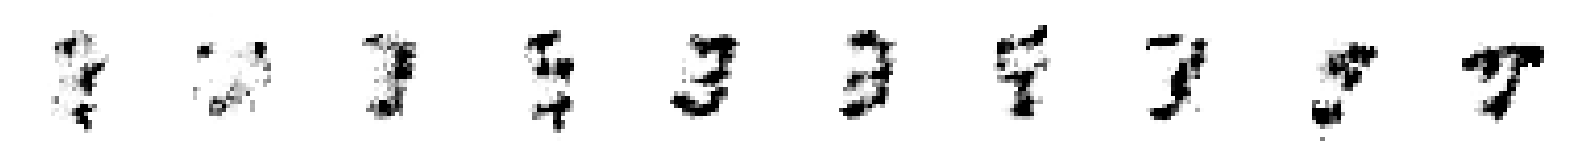


Saved to ./output/example_img_009.png


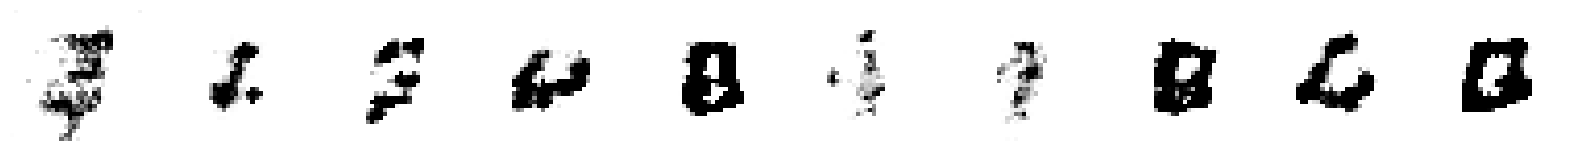

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 664ms/step - cdiv: -0.0314 - fake: -0.0115 - loss: -0.0224 - real: 0.0199 - reg: 0.0090 - val_cdiv: -13.8549 - val_fake: -13.7031 - val_real: 0.1518
Epoch 11/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - cdiv: -0.0265 - fake: -0.0032 - loss: -0.0184 - real: 0.0233 - reg: 0.0082
Saved to ./output/generated_img_010.png


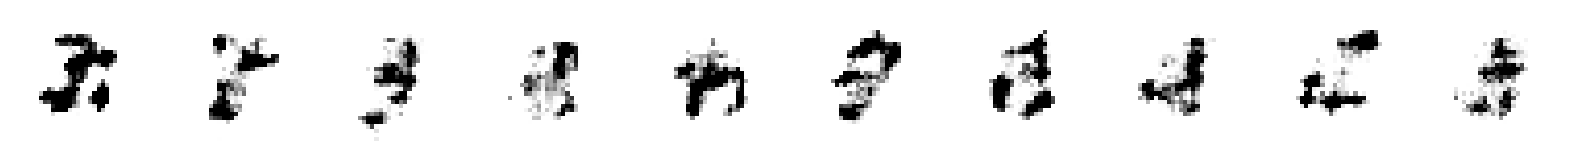


Saved to ./output/example_img_010.png


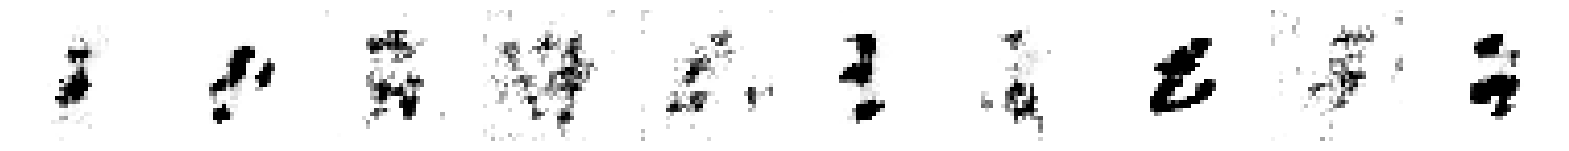

235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 667ms/step - cdiv: -0.0245 - fake: -0.0099 - loss: -0.0173 - real: 0.0146 - reg: 0.0072 - val_cdiv: -15.6779 - val_fake: -15.5948 - val_real: 0.0831
Epoch 12/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - cdiv: -0.0230 - fake: -0.0089 - loss: -0.0165 - real: 0.0140 - reg: 0.0065
Saved to ./output/generated_img_011.png


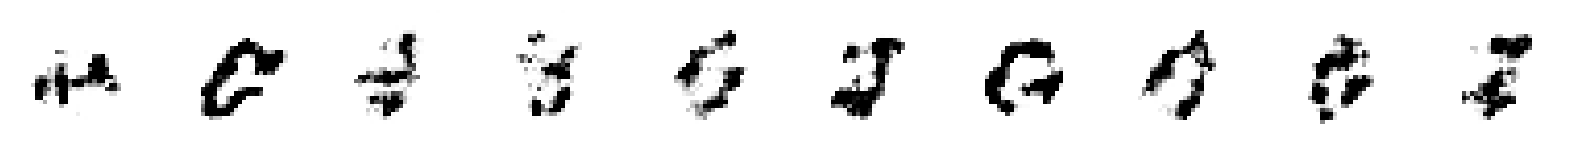


Saved to ./output/example_img_011.png


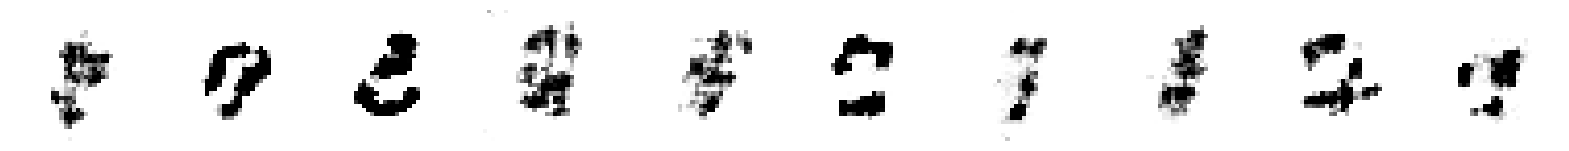

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 664ms/step - cdiv: -0.0237 - fake: -0.0124 - loss: -0.0172 - real: 0.0113 - reg: 0.0065 - val_cdiv: -17.8644 - val_fake: -17.7984 - val_real: 0.0660
Epoch 13/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - cdiv: -0.0330 - fake: -0.0090 - loss: -0.0232 - real: 0.0240 - reg: 0.0098
Saved to ./output/generated_img_012.png


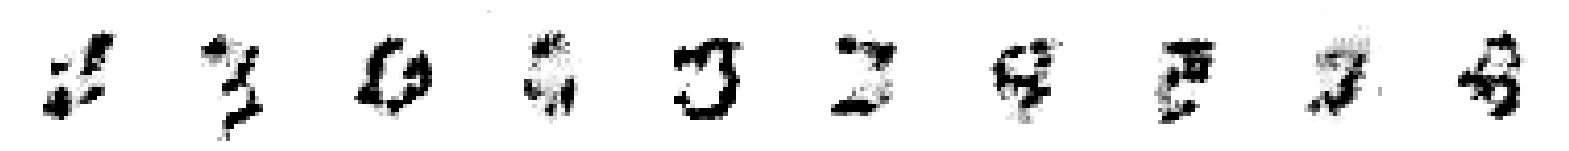


Saved to ./output/example_img_012.png


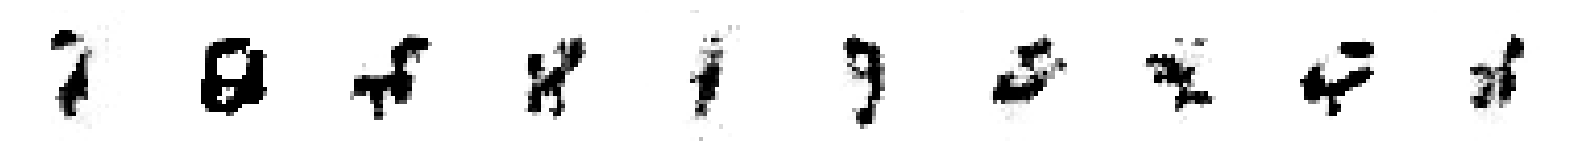

235/235 ━━━━━━━━━━━━━━━━━━━━ 158s 674ms/step - cdiv: -0.0308 - fake: -0.0125 - loss: -0.0222 - real: 0.0183 - reg: 0.0087 - val_cdiv: -20.4567 - val_fake: -20.3837 - val_real: 0.0730
Epoch 14/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - cdiv: -0.0414 - fake: -0.0200 - loss: -0.0277 - real: 0.0214 - reg: 0.0137
Saved to ./output/generated_img_013.png


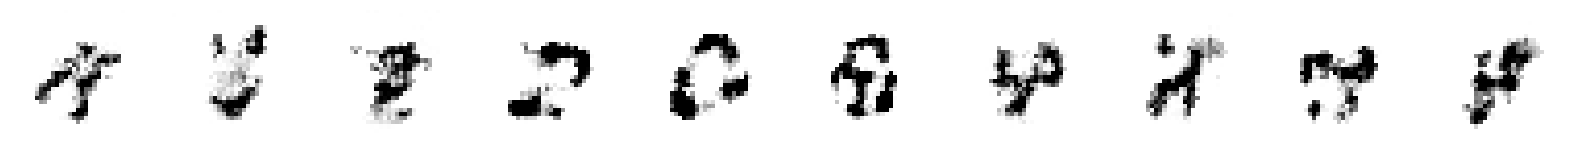


Saved to ./output/example_img_013.png


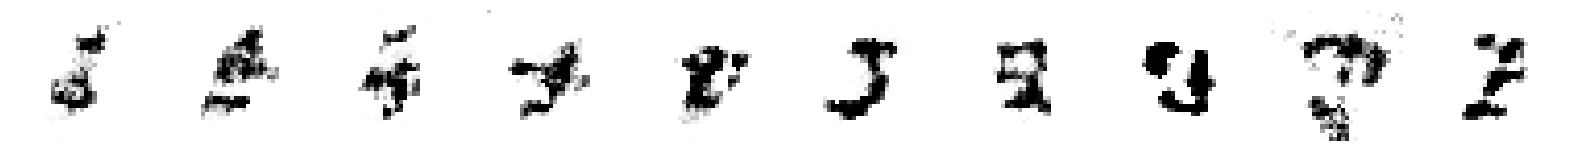

235/235 ━━━━━━━━━━━━━━━━━━━━ 160s 680ms/step - cdiv: -0.0383 - fake: -0.0188 - loss: -0.0256 - real: 0.0194 - reg: 0.0127 - val_cdiv: -23.2465 - val_fake: -23.1706 - val_real: 0.0759
Epoch 15/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - cdiv: -0.0550 - fake: -0.0246 - loss: -0.0332 - real: 0.0304 - reg: 0.0218
Saved to ./output/generated_img_014.png


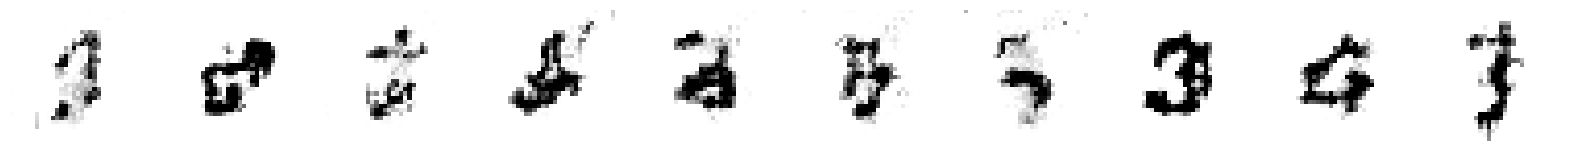


Saved to ./output/example_img_014.png


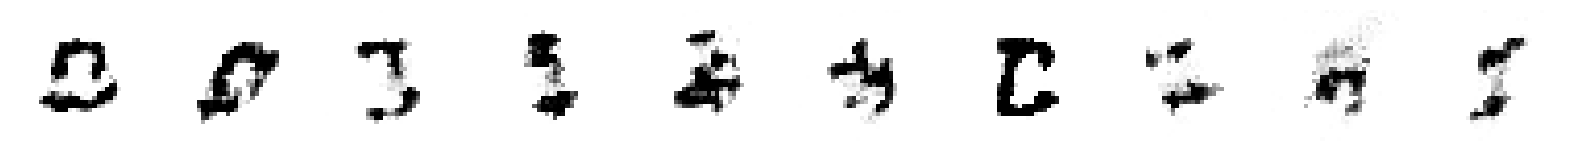

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 664ms/step - cdiv: -0.0557 - fake: -0.0267 - loss: -0.0333 - real: 0.0289 - reg: 0.0224 - val_cdiv: -25.7880 - val_fake: -25.7196 - val_real: 0.0684
Epoch 16/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - cdiv: -0.2050 - fake: -0.1104 - loss: -0.0959 - real: 0.0946 - reg: 0.1091
Saved to ./output/generated_img_015.png


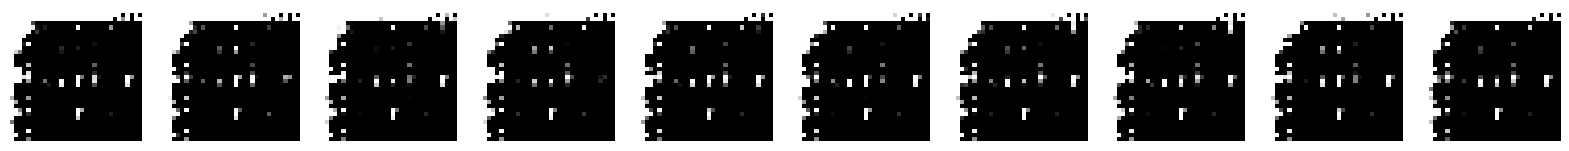


Saved to ./output/example_img_015.png


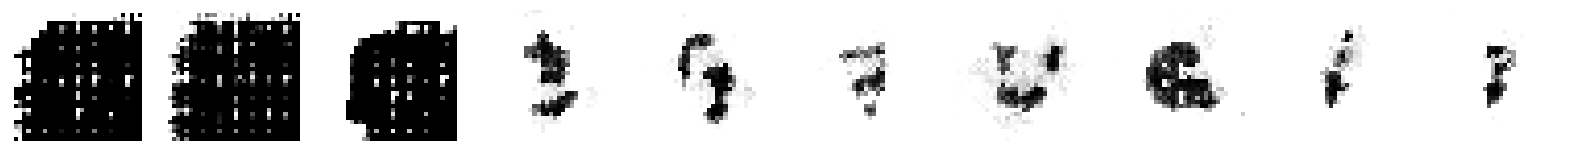

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 665ms/step - cdiv: -0.5330 - fake: -0.2936 - loss: -0.2486 - real: 0.2394 - reg: 0.2843 - val_cdiv: -21.2420 - val_fake: -20.5041 - val_real: 0.7379
Epoch 17/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - cdiv: -2.5374 - fake: -1.3169 - loss: -1.2809 - real: 1.2205 - reg: 1.2566
Saved to ./output/generated_img_016.png


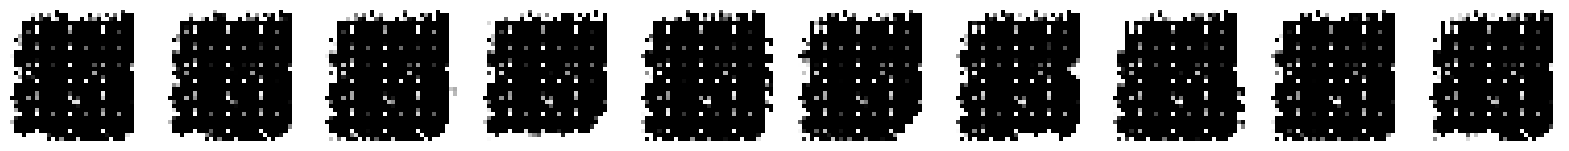


Saved to ./output/example_img_016.png


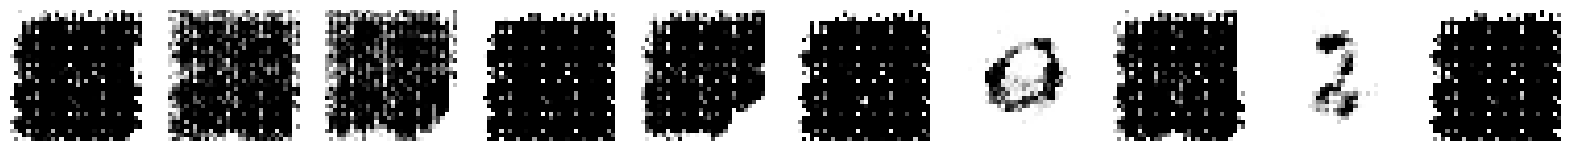

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 663ms/step - cdiv: -3.3202 - fake: -1.7121 - loss: -1.6522 - real: 1.6081 - reg: 1.6680 - val_cdiv: -20.3444 - val_fake: -17.9881 - val_real: 2.3563
Epoch 18/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - cdiv: -5.3001 - fake: -2.6482 - loss: -2.6839 - real: 2.6519 - reg: 2.6162
Saved to ./output/generated_img_017.png


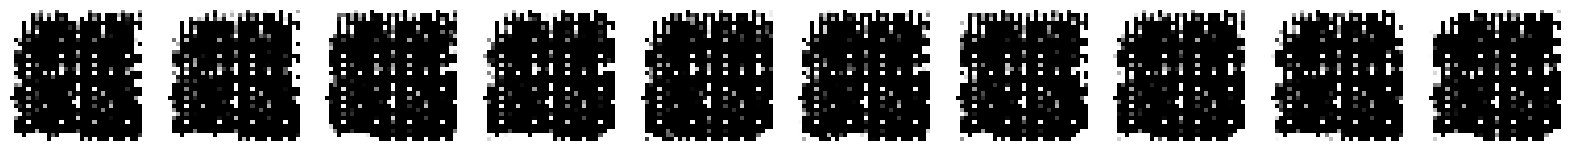


Saved to ./output/example_img_017.png


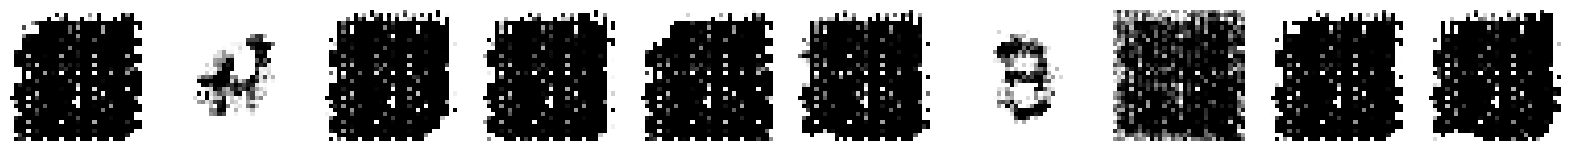

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 663ms/step - cdiv: -5.9642 - fake: -3.0100 - loss: -2.9862 - real: 2.9542 - reg: 2.9781 - val_cdiv: -20.6364 - val_fake: -17.1097 - val_real: 3.5267
Epoch 19/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - cdiv: -7.3213 - fake: -3.6394 - loss: -3.6939 - real: 3.6819 - reg: 3.6274
Saved to ./output/generated_img_018.png


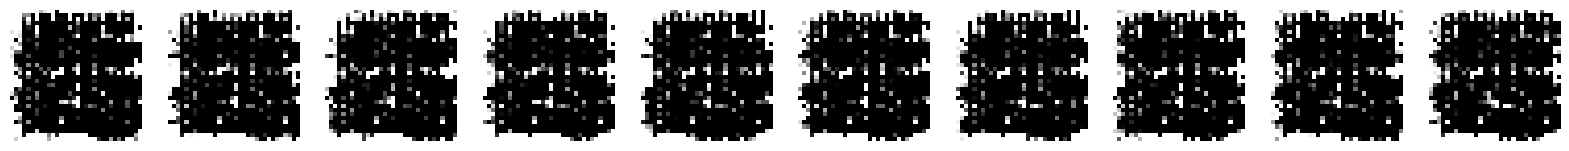


Saved to ./output/example_img_018.png


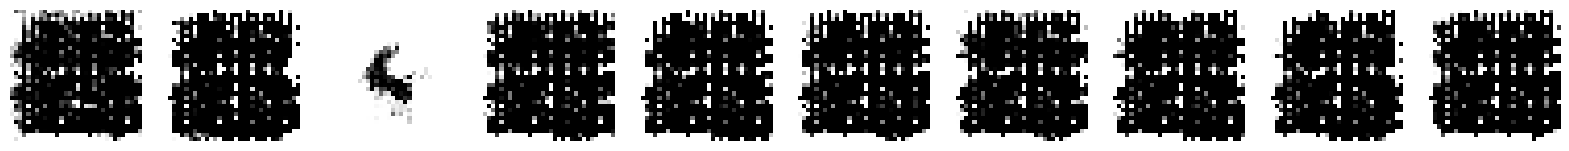

235/235 ━━━━━━━━━━━━━━━━━━━━ 153s 653ms/step - cdiv: -7.7095 - fake: -3.8688 - loss: -3.8525 - real: 3.8407 - reg: 3.8570 - val_cdiv: -20.1625 - val_fake: -15.9369 - val_real: 4.2257
Epoch 20/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - cdiv: -8.5357 - fake: -4.2345 - loss: -4.3046 - real: 4.3013 - reg: 4.2311
Saved to ./output/generated_img_019.png


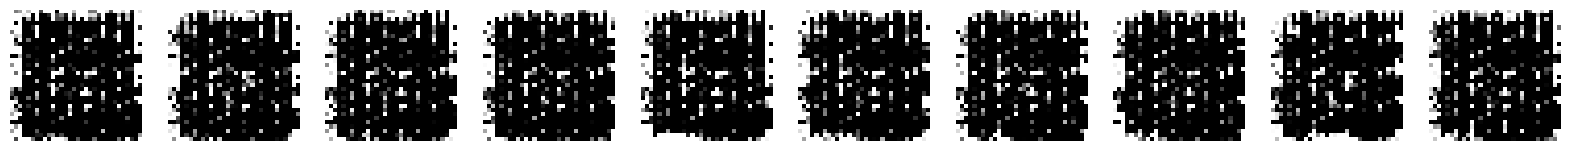


Saved to ./output/example_img_019.png


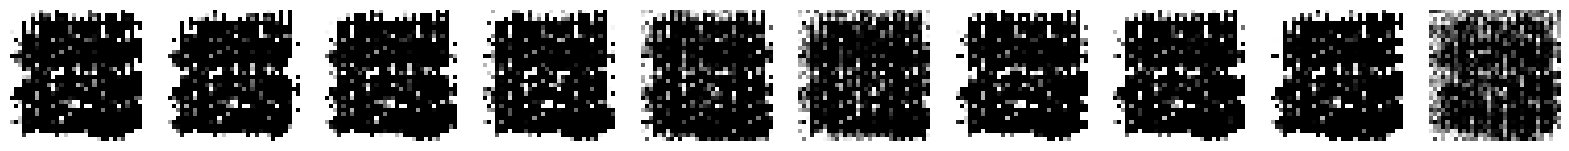

235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 663ms/step - cdiv: -8.8445 - fake: -4.4325 - loss: -4.4223 - real: 4.4121 - reg: 4.4222 - val_cdiv: -19.6402 - val_fake: -14.9992 - val_real: 4.6410
Epoch 21/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - cdiv: -9.3224 - fake: -4.6131 - loss: -4.6920 - real: 4.7093 - reg: 4.6304
Saved to ./output/generated_img_020.png


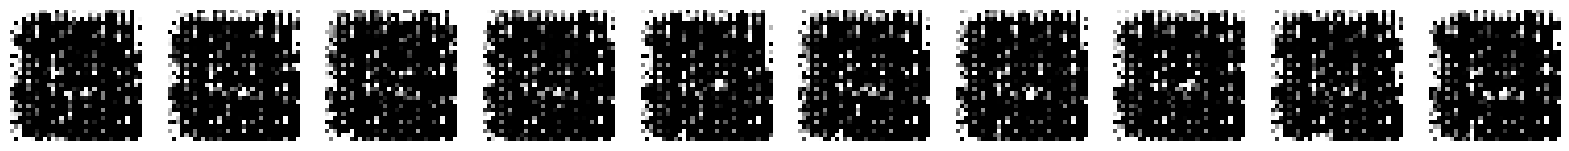


Saved to ./output/example_img_020.png


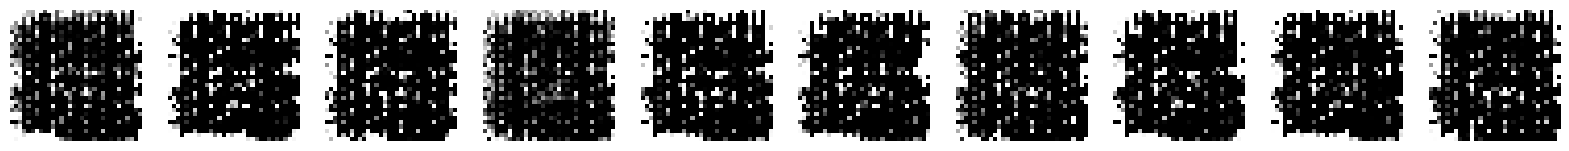

235/235 ━━━━━━━━━━━━━━━━━━━━ 200s 656ms/step - cdiv: -9.5120 - fake: -4.7576 - loss: -4.7514 - real: 4.7544 - reg: 4.7606 - val_cdiv: -19.2366 - val_fake: -14.3727 - val_real: 4.8639
Epoch 22/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - cdiv: -9.6574 - fake: -4.7819 - loss: -4.8627 - real: 4.8755 - reg: 4.7946
Saved to ./output/generated_img_021.png


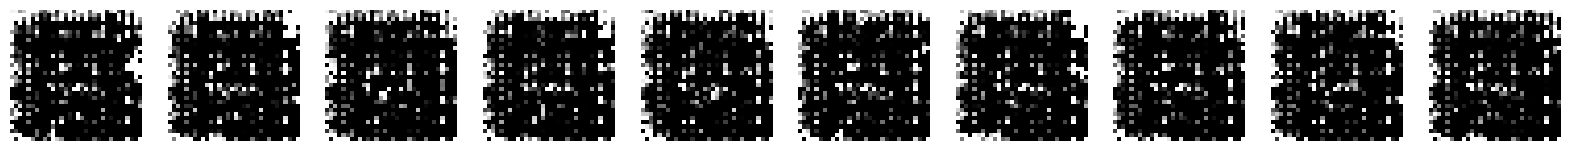


Saved to ./output/example_img_021.png


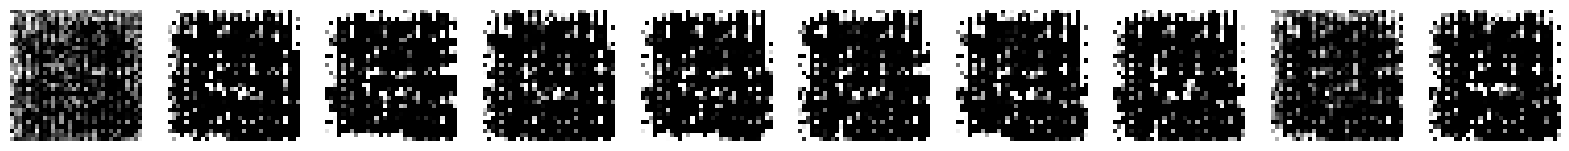

235/235 ━━━━━━━━━━━━━━━━━━━━ 158s 674ms/step - cdiv: -9.7371 - fake: -4.8688 - loss: -4.8629 - real: 4.8682 - reg: 4.8741 - val_cdiv: -18.6571 - val_fake: -13.7461 - val_real: 4.9109
Epoch 23/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - cdiv: -9.7798 - fake: -4.8420 - loss: -4.9216 - real: 4.9378 - reg: 4.8582
Saved to ./output/generated_img_022.png


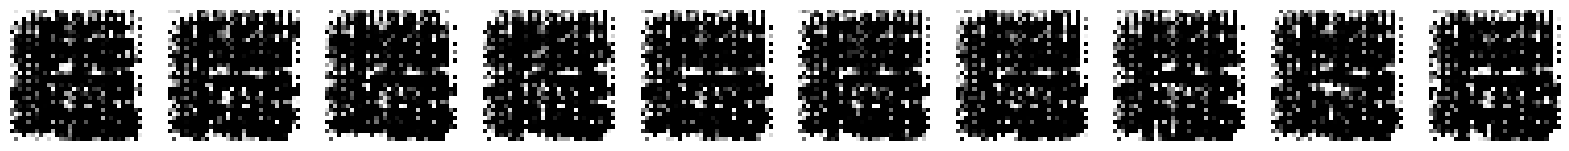


Saved to ./output/example_img_022.png


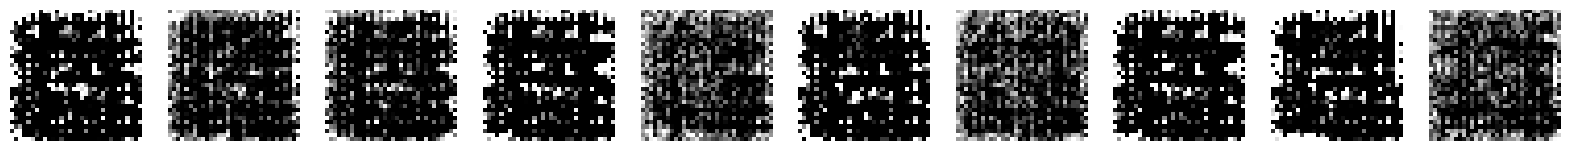

235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 670ms/step - cdiv: -9.8620 - fake: -4.9311 - loss: -4.9251 - real: 4.9310 - reg: 4.9369 - val_cdiv: -18.0225 - val_fake: -13.0760 - val_real: 4.9465
Epoch 24/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - cdiv: -9.8755 - fake: -4.8902 - loss: -4.9720 - real: 4.9853 - reg: 4.9035
Saved to ./output/generated_img_023.png


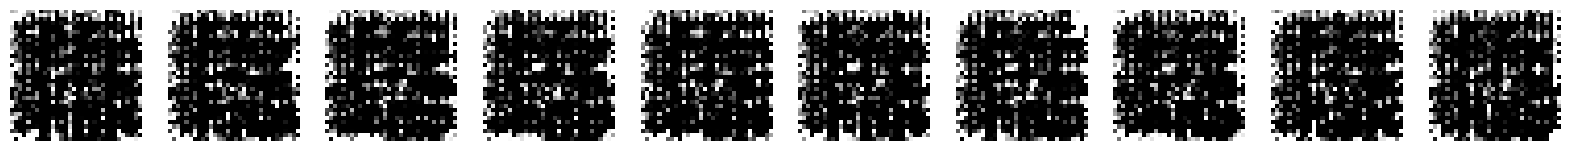


Saved to ./output/example_img_023.png


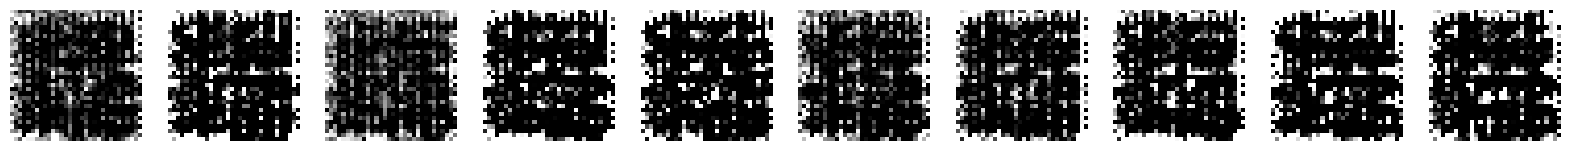

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 677ms/step - cdiv: -9.9339 - fake: -4.9659 - loss: -4.9618 - real: 4.9680 - reg: 4.9720 - val_cdiv: -17.6501 - val_fake: -12.6713 - val_real: 4.9788
Epoch 25/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - cdiv: -9.9012 - fake: -4.9044 - loss: -4.9857 - real: 4.9968 - reg: 4.9155
Saved to ./output/generated_img_024.png


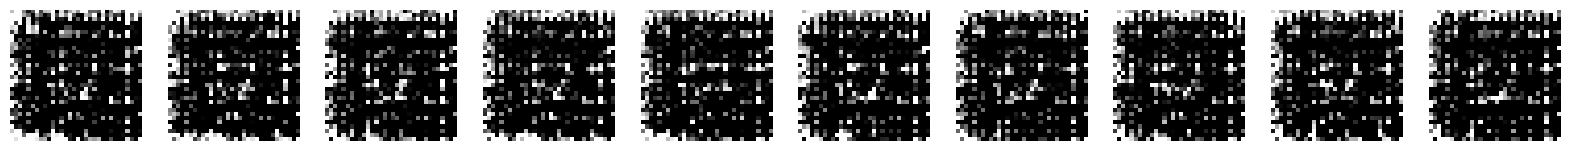


Saved to ./output/example_img_024.png


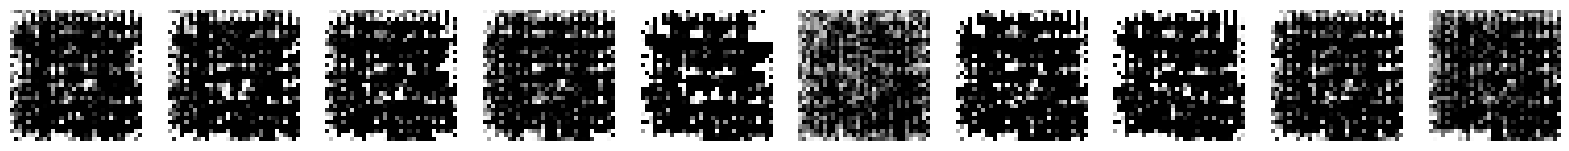

235/235 ━━━━━━━━━━━━━━━━━━━━ 158s 671ms/step - cdiv: -9.9570 - fake: -4.9773 - loss: -4.9741 - real: 4.9797 - reg: 4.9829 - val_cdiv: -17.3597 - val_fake: -12.3705 - val_real: 4.9892
Epoch 26/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - cdiv: -9.9021 - fake: -4.9038 - loss: -4.9859 - real: 4.9983 - reg: 4.9162
Saved to ./output/generated_img_025.png


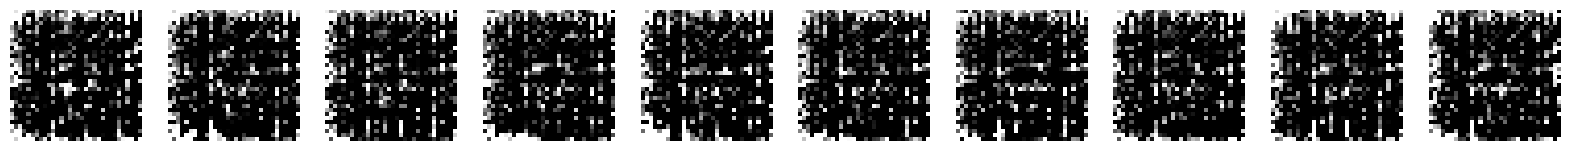


Saved to ./output/example_img_025.png


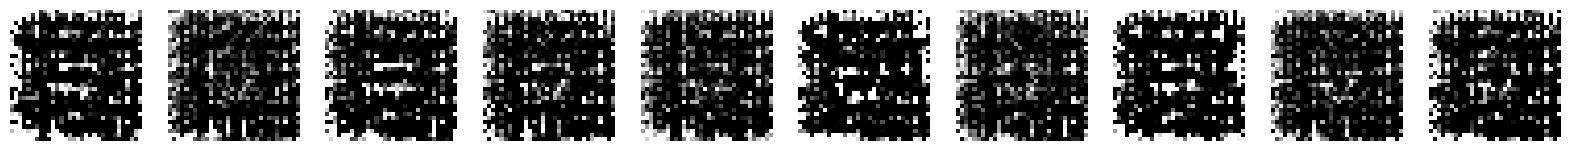

235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 670ms/step - cdiv: -9.9582 - fake: -4.9781 - loss: -4.9741 - real: 4.9801 - reg: 4.9841 - val_cdiv: -16.8490 - val_fake: -11.8586 - val_real: 4.9904
Epoch 27/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - cdiv: -9.9043 - fake: -4.9057 - loss: -4.9867 - real: 4.9986 - reg: 4.9176
Saved to ./output/generated_img_026.png


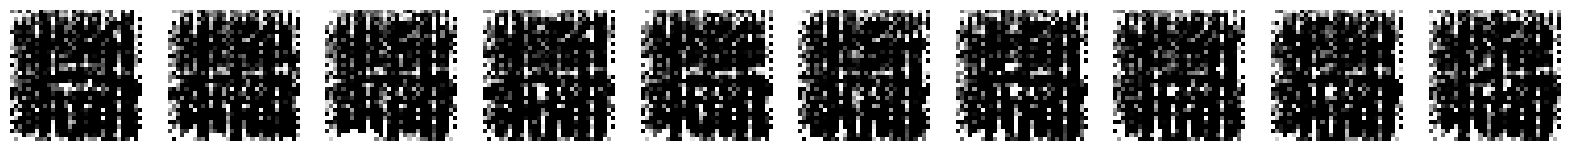


Saved to ./output/example_img_026.png


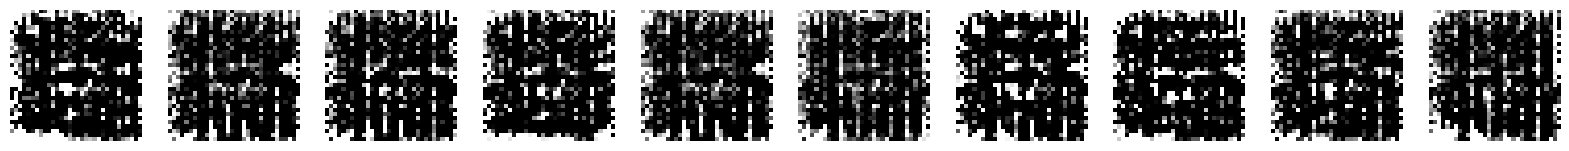

235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 668ms/step - cdiv: -9.9589 - fake: -4.9786 - loss: -4.9747 - real: 4.9802 - reg: 4.9842 - val_cdiv: -16.4286 - val_fake: -11.4398 - val_real: 4.9888
Epoch 28/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - cdiv: -9.9057 - fake: -4.9071 - loss: -4.9874 - real: 4.9986 - reg: 4.9182
Saved to ./output/generated_img_027.png


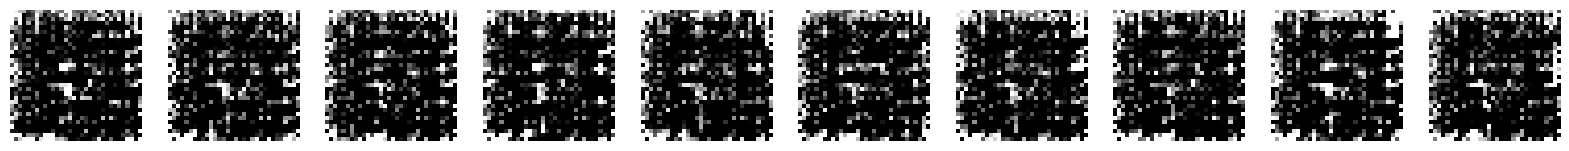


Saved to ./output/example_img_027.png


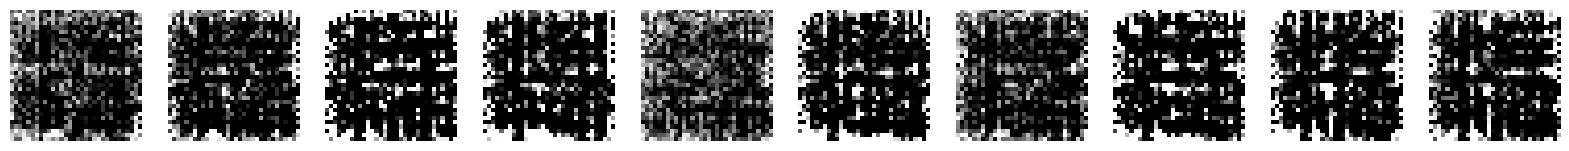

235/235 ━━━━━━━━━━━━━━━━━━━━ 157s 668ms/step - cdiv: -9.9584 - fake: -4.9782 - loss: -4.9749 - real: 4.9802 - reg: 4.9835 - val_cdiv: -16.1449 - val_fake: -11.1546 - val_real: 4.9903
Epoch 29/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - cdiv: -9.9066 - fake: -4.9079 - loss: -4.9884 - real: 4.9987 - reg: 4.9182
Saved to ./output/generated_img_028.png


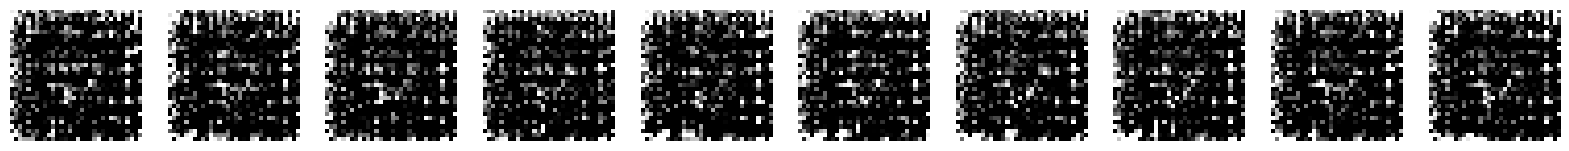


Saved to ./output/example_img_028.png


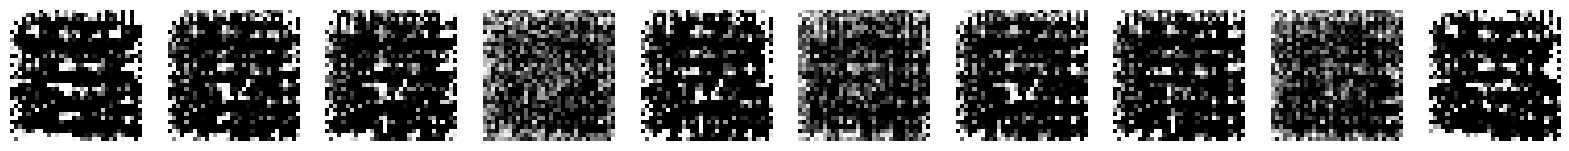

235/235 ━━━━━━━━━━━━━━━━━━━━ 158s 671ms/step - cdiv: -9.9586 - fake: -4.9783 - loss: -4.9752 - real: 4.9803 - reg: 4.9834 - val_cdiv: -15.8387 - val_fake: -10.8535 - val_real: 4.9852
Epoch 30/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - cdiv: -9.9059 - fake: -4.9073 - loss: -4.9881 - real: 4.9987 - reg: 4.9178
Saved to ./output/generated_img_029.png


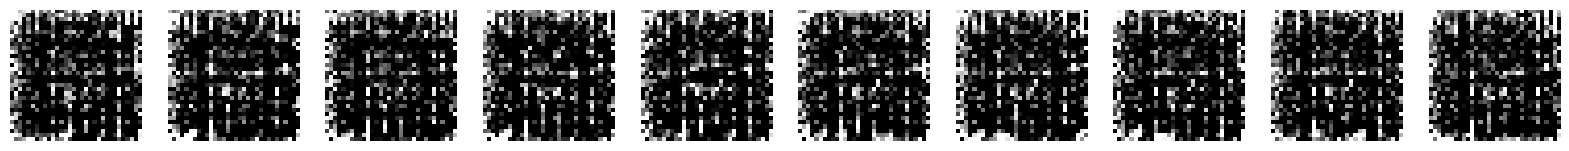


Saved to ./output/example_img_029.png


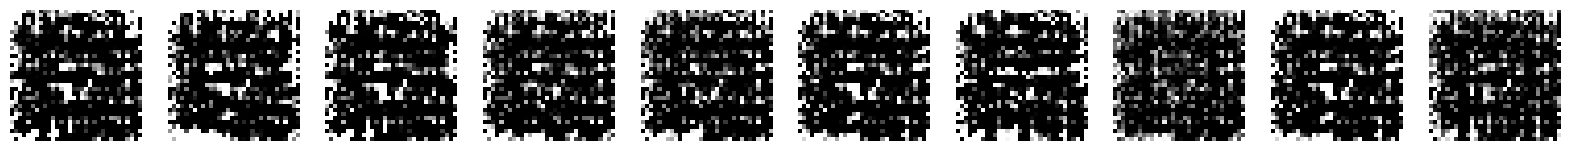

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 678ms/step - cdiv: -9.9591 - fake: -4.9787 - loss: -4.9753 - real: 4.9804 - reg: 4.9838 - val_cdiv: -15.4343 - val_fake: -10.4510 - val_real: 4.9833
Epoch 31/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - cdiv: -9.9076 - fake: -4.9091 - loss: -4.9890 - real: 4.9986 - reg: 4.9186
Saved to ./output/generated_img_030.png


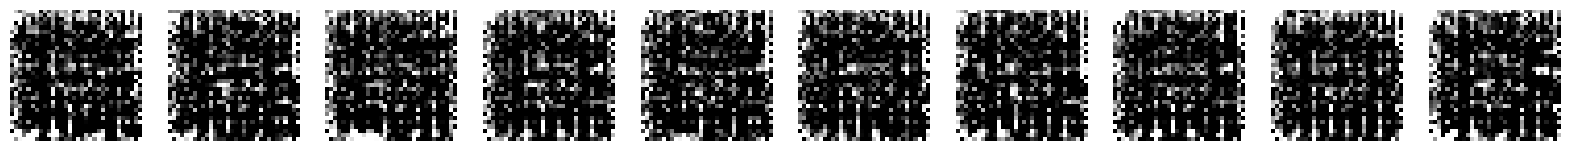


Saved to ./output/example_img_030.png


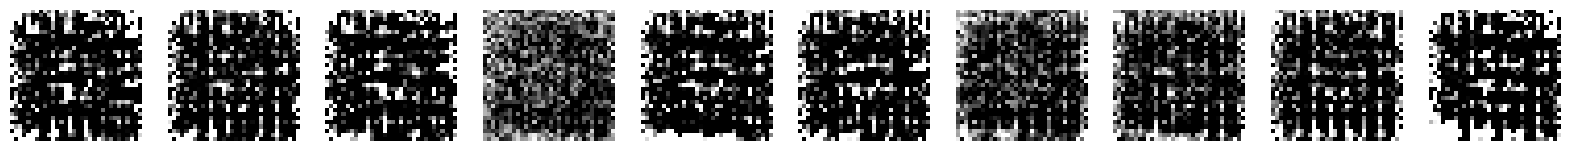

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 676ms/step - cdiv: -9.9594 - fake: -4.9790 - loss: -4.9756 - real: 4.9804 - reg: 4.9838 - val_cdiv: -15.0839 - val_fake: -10.1025 - val_real: 4.9814
Epoch 32/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - cdiv: -9.9089 - fake: -4.9103 - loss: -4.9897 - real: 4.9986 - reg: 4.9192
Saved to ./output/generated_img_031.png


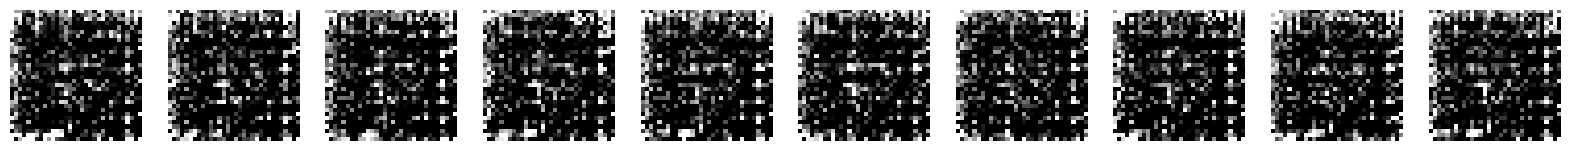


Saved to ./output/example_img_031.png


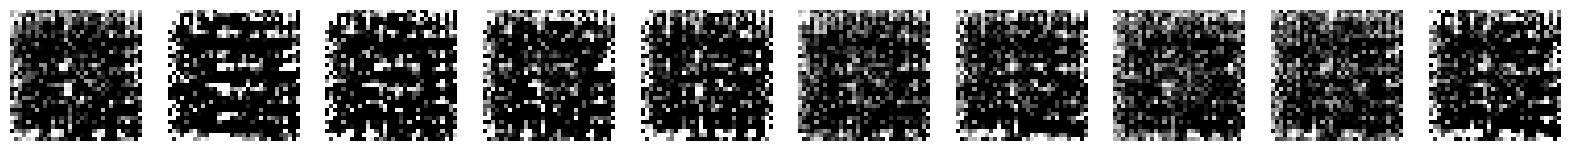

235/235 ━━━━━━━━━━━━━━━━━━━━ 160s 679ms/step - cdiv: -9.9588 - fake: -4.9784 - loss: -4.9759 - real: 4.9803 - reg: 4.9829 - val_cdiv: -14.8318 - val_fake: -9.8558 - val_real: 4.9760
Epoch 33/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - cdiv: -9.9083 - fake: -4.9098 - loss: -4.9899 - real: 4.9984 - reg: 4.9183
Saved to ./output/generated_img_032.png


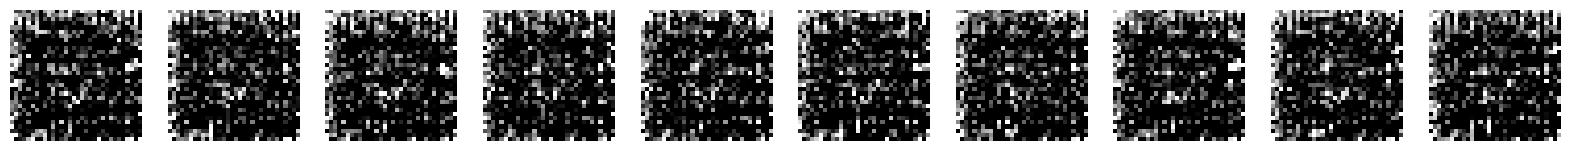


Saved to ./output/example_img_032.png


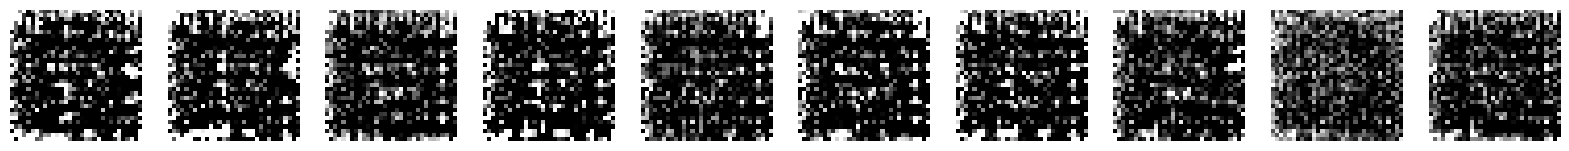

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 677ms/step - cdiv: -9.9589 - fake: -4.9785 - loss: -4.9760 - real: 4.9803 - reg: 4.9829 - val_cdiv: -14.5406 - val_fake: -9.5678 - val_real: 4.9727
Epoch 34/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - cdiv: -9.9098 - fake: -4.9112 - loss: -4.9902 - real: 4.9986 - reg: 4.9196
Saved to ./output/generated_img_033.png


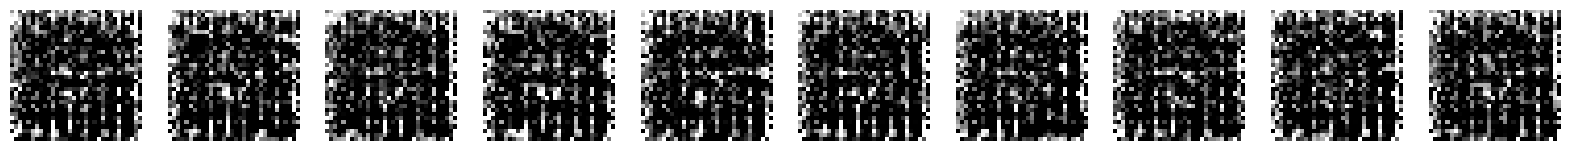


Saved to ./output/example_img_033.png


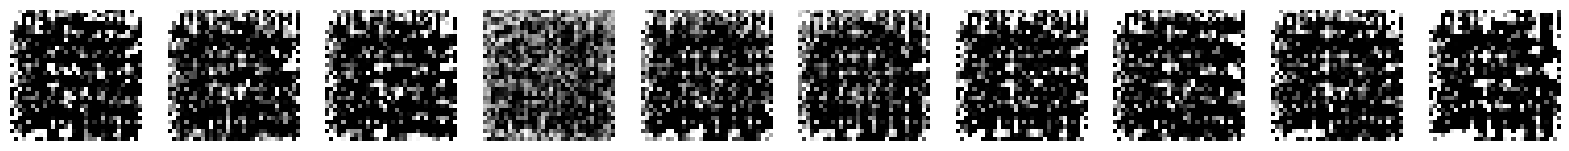

235/235 ━━━━━━━━━━━━━━━━━━━━ 202s 678ms/step - cdiv: -9.9599 - fake: -4.9794 - loss: -4.9763 - real: 4.9805 - reg: 4.9835 - val_cdiv: -14.1975 - val_fake: -9.2300 - val_real: 4.9676
Epoch 35/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - cdiv: -9.9110 - fake: -4.9126 - loss: -4.9906 - real: 4.9984 - reg: 4.9204
Saved to ./output/generated_img_034.png


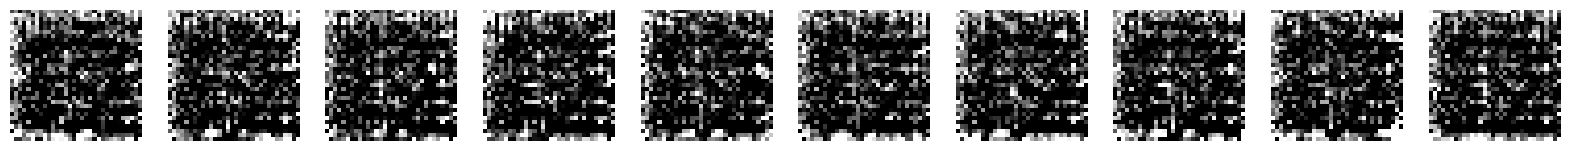


Saved to ./output/example_img_034.png


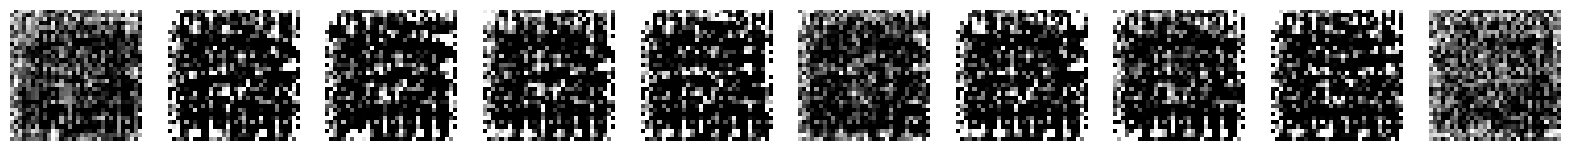

235/235 ━━━━━━━━━━━━━━━━━━━━ 158s 674ms/step - cdiv: -9.9595 - fake: -4.9792 - loss: -4.9762 - real: 4.9803 - reg: 4.9833 - val_cdiv: -13.9154 - val_fake: -8.9484 - val_real: 4.9670
Epoch 36/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - cdiv: -9.9115 - fake: -4.9130 - loss: -4.9914 - real: 4.9984 - reg: 4.9200
Saved to ./output/generated_img_035.png


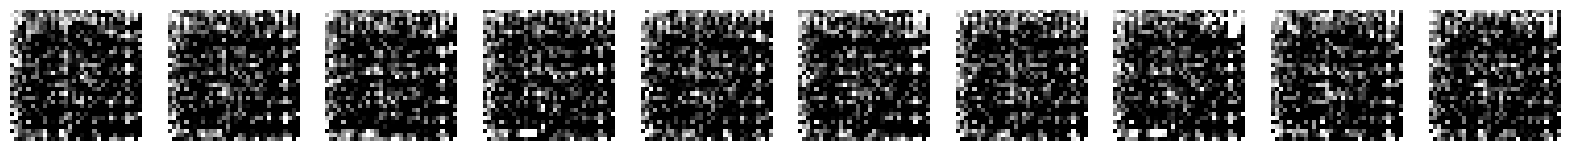


Saved to ./output/example_img_035.png


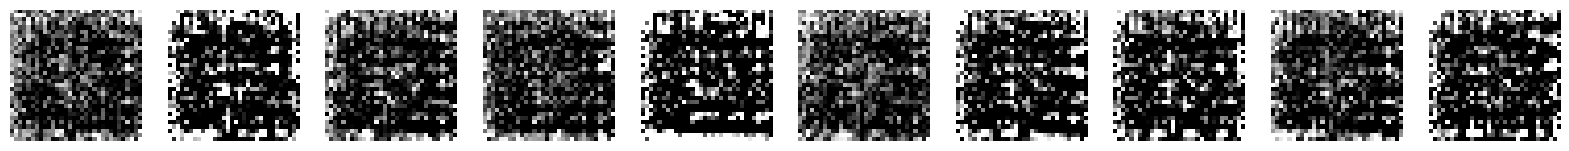

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 676ms/step - cdiv: -9.9586 - fake: -4.9782 - loss: -4.9766 - real: 4.9804 - reg: 4.9820 - val_cdiv: -13.7175 - val_fake: -8.7520 - val_real: 4.9654
Epoch 37/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - cdiv: -9.9110 - fake: -4.9126 - loss: -4.9914 - real: 4.9984 - reg: 4.9196
Saved to ./output/generated_img_036.png


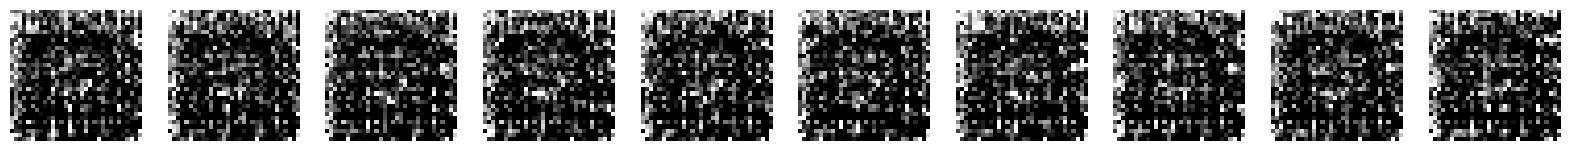


Saved to ./output/example_img_036.png


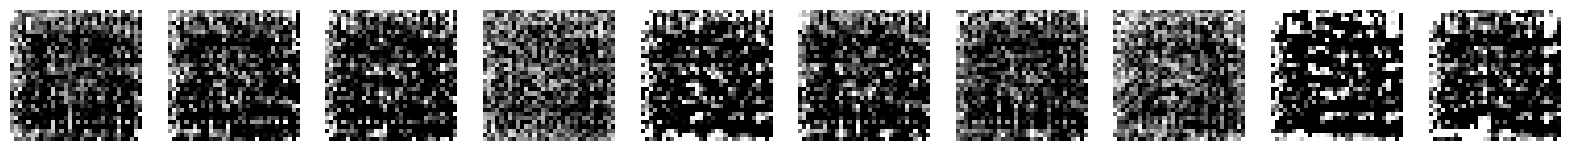

235/235 ━━━━━━━━━━━━━━━━━━━━ 200s 670ms/step - cdiv: -9.9590 - fake: -4.9785 - loss: -4.9769 - real: 4.9804 - reg: 4.9821 - val_cdiv: -13.4681 - val_fake: -8.5048 - val_real: 4.9633
Epoch 38/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - cdiv: -9.9072 - fake: -4.9115 - loss: -4.9891 - real: 4.9957 - reg: 4.9181
Saved to ./output/generated_img_037.png


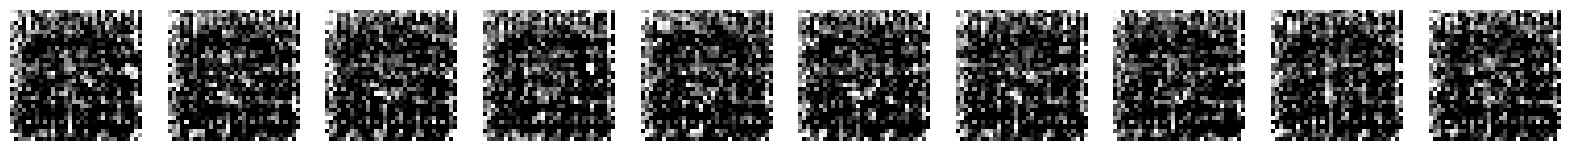


Saved to ./output/example_img_037.png


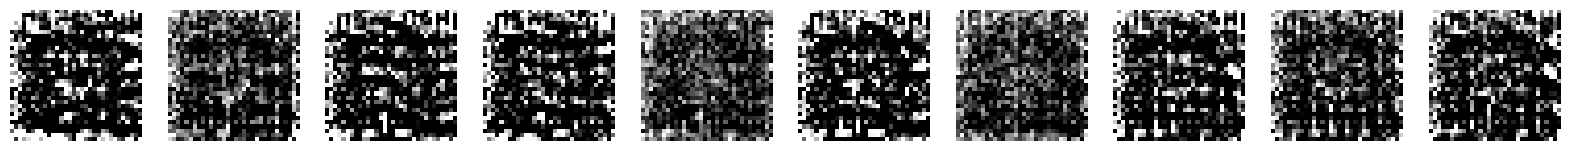

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 675ms/step - cdiv: -9.9347 - fake: -4.9660 - loss: -4.9655 - real: 4.9687 - reg: 4.9692 - val_cdiv: -13.3588 - val_fake: -8.4220 - val_real: 4.9368
Epoch 39/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - cdiv: -9.9023 - fake: -4.9106 - loss: -4.9852 - real: 4.9917 - reg: 4.9171
Saved to ./output/generated_img_038.png


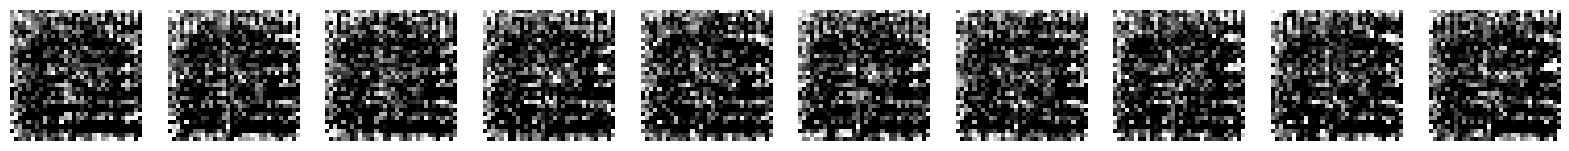


Saved to ./output/example_img_038.png


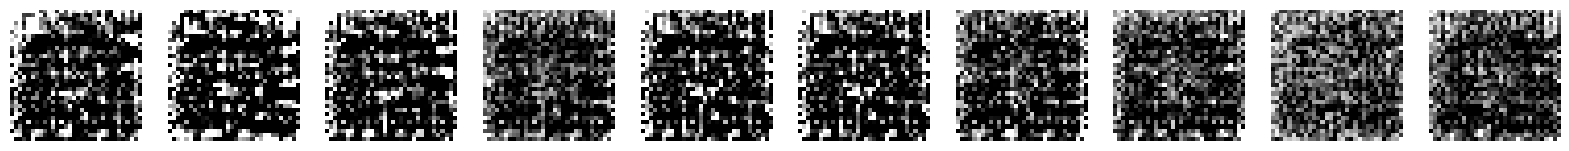

235/235 ━━━━━━━━━━━━━━━━━━━━ 161s 684ms/step - cdiv: -9.9557 - fake: -4.9778 - loss: -4.9746 - real: 4.9779 - reg: 4.9811 - val_cdiv: -13.1367 - val_fake: -8.1640 - val_real: 4.9728
Epoch 40/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - cdiv: -9.8939 - fake: -4.9038 - loss: -4.9843 - real: 4.9901 - reg: 4.9096
Saved to ./output/generated_img_039.png


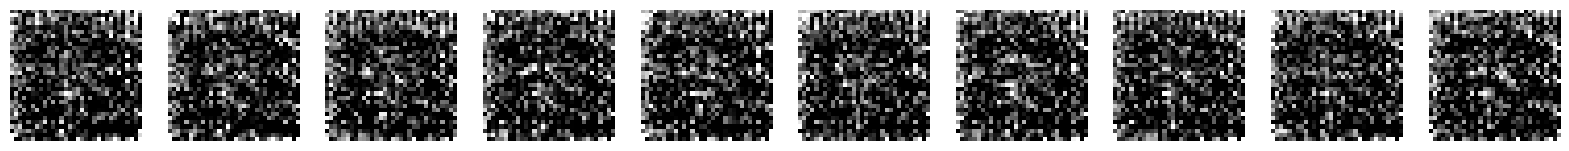


Saved to ./output/example_img_039.png


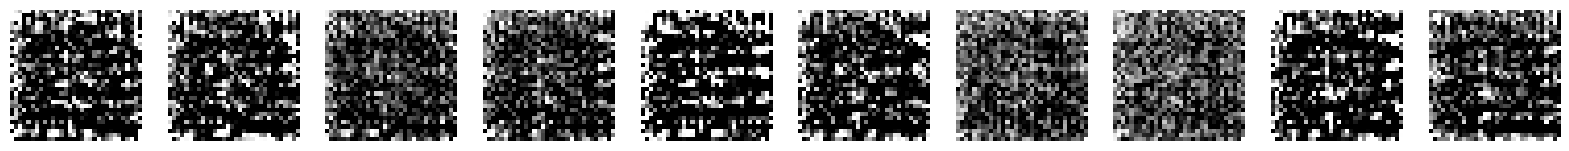

235/235 ━━━━━━━━━━━━━━━━━━━━ 159s 678ms/step - cdiv: -9.9214 - fake: -4.9596 - loss: -4.9595 - real: 4.9618 - reg: 4.9619 - val_cdiv: -12.9604 - val_fake: -8.0131 - val_real: 4.9473


In [105]:
class SaveModel(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        model.save_weights("./models/model.weights.h5")

save_model_callback = SaveModel()

history = ebm.fit(
    x_train,
    shuffle=True,
    epochs=EPOCHS,
    validation_data=x_test,
    callbacks=[
        save_model_callback,
        tensorboard_callback,
        image_generator_callback,
    ],
)

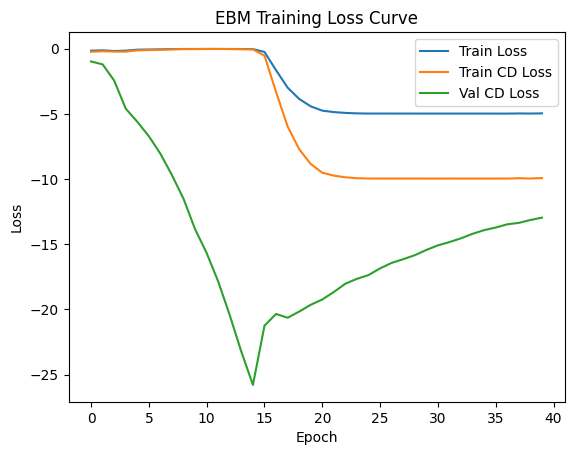

In [106]:

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['cdiv'], label='Train CD Loss')
plt.plot(history.history['val_cdiv'], label='Val CD Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('EBM Training Loss Curve')
plt.savefig("loss_curve.png")
plt.show()


## 4. Generate images <a name="generate"></a>

In [107]:
start_imgs = (
    np.random.uniform(size=(10, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
)

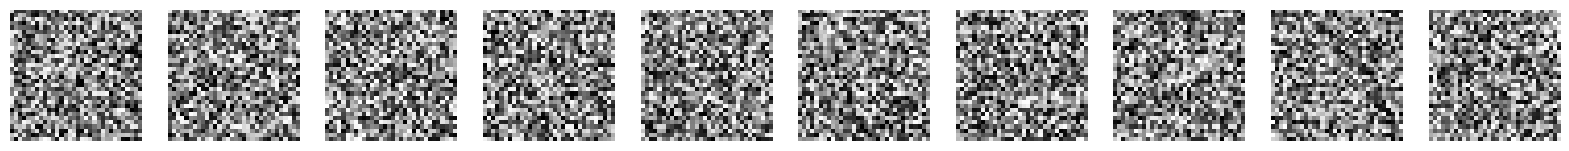

In [108]:
display(start_imgs)

In [109]:
gen_img = generate_samples(
    ebm.model,
    start_imgs,
    steps=1000,
    step_size=STEP_SIZE,
    noise=NOISE,
    return_img_per_step=True,
)

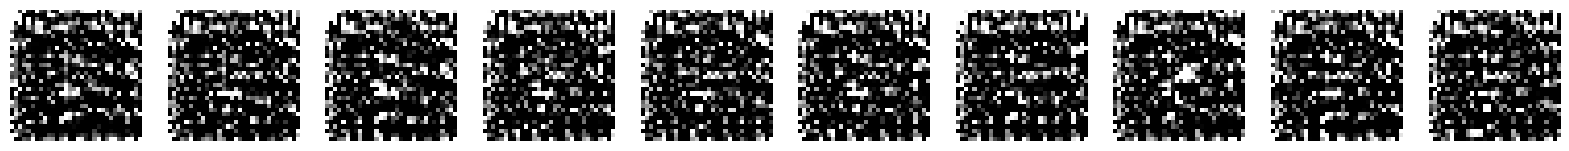

In [110]:
display(gen_img[-1].numpy())

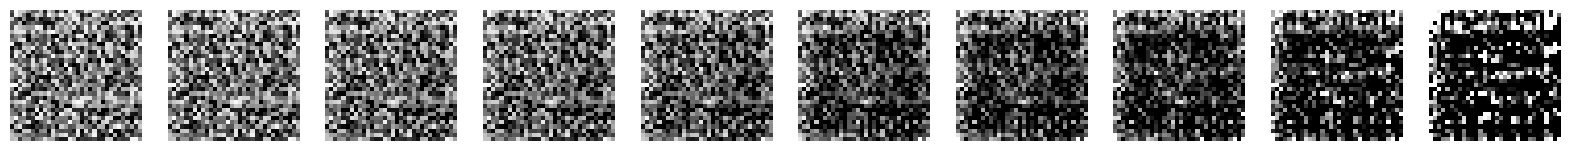

In [111]:
imgs = []
for i in [0, 1, 3, 5, 10, 30, 50, 100, 300, 999]:
    imgs.append(gen_img[i].numpy()[6])

display(np.array(imgs))